# Day 36/60 — Forecasting Customer Growth Trends

## Time Series Analytics

Forecasting future customer growth using historical business data.

In [1]:
# DAY 36 - FORECASTING CUSTOMER GROWTH TRENDS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Day 36 libraries imported successfully!")

Day 36 libraries imported successfully!


In [2]:
# Load historical sales data

df = pd.read_csv("../cleaned_dataset.csv")

print("Historical sales dataset loaded successfully!")
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Historical sales dataset loaded successfully!
Dataset shape: (51290, 23)

Columns:
['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name', 'segment', 'state', 'country', 'market', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'order_priority', 'year', 'shipping_days', 'profit_margin']


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,shipping_days,profit_margin
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,"Tenex Lockers, Blue",408.0,2,0.0,106.140,35.46,Medium,2011,5,26.014706
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,"Acme Trimmer, High Speed",120.0,3,0.1,36.036,9.72,Medium,2011,7,30.030000
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,"Tenex Box, Single Width",66.0,4,0.0,29.640,8.17,High,2011,4,44.909091
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,"Enermax Note Cards, Premium",45.0,3,0.5,-26.055,4.82,High,2011,4,-57.900000
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,"Eldon Light Bulb, Duo Pack",114.0,5,0.1,37.770,4.70,Medium,2011,7,33.131579


In [3]:
# Prepare daily customer growth data

df["order_date"] = pd.to_datetime(df["order_date"])

daily_customers = (
    df.groupby("order_date")["customer_name"]
    .nunique()
    .reset_index()
)

daily_customers.columns = [
    "date",
    "unique_customers"
]

daily_customers = daily_customers.sort_values("date")

print("Daily customer growth data created successfully!")

print("\nDate range:")
print(daily_customers["date"].min(), "to", daily_customers["date"].max())

print("\nDaily customer data shape:")
print(daily_customers.shape)

display(daily_customers.head(10))

Daily customer growth data created successfully!

Date range:
2011-01-01 00:00:00 to 2014-12-31 00:00:00

Daily customer data shape:
(1430, 2)


,date,unique_customers
0,2011-01-01,4
1,2011-01-02,1
2,2011-01-03,11
3,2011-01-04,9
4,2011-01-05,4
5,2011-01-06,6
6,2011-01-07,11
7,2011-01-08,6
8,2011-01-09,3
9,2011-01-10,11


In [4]:
# Create a continuous daily time series

daily_customers = (
    daily_customers
    .set_index("date")
    .asfreq("D", fill_value=0)
    .reset_index()
)

print("Continuous daily time series created successfully!")

print("\nUpdated shape:", daily_customers.shape)

print("\nMissing values:")
print(daily_customers.isnull().sum())

display(daily_customers.head(10))

Continuous daily time series created successfully!

Updated shape: (1461, 2)

Missing values:
date                0
unique_customers    0
dtype: int64


,date,unique_customers
0,2011-01-01,4
1,2011-01-02,1
2,2011-01-03,11
3,2011-01-04,9
4,2011-01-05,4
5,2011-01-06,6
6,2011-01-07,11
7,2011-01-08,6
8,2011-01-09,3
9,2011-01-10,11


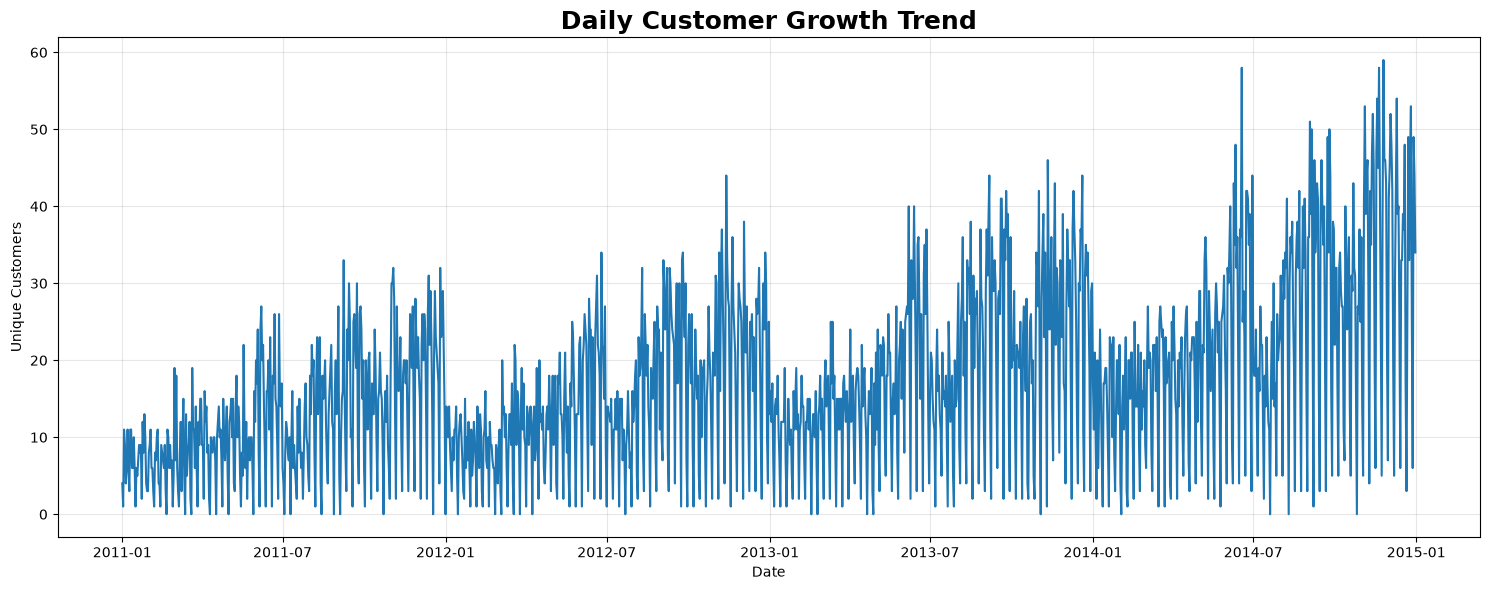

Customer growth trend visualization created successfully!


In [5]:
# Visualize daily customer growth

plt.figure(figsize=(15, 6))

plt.plot(
    daily_customers["date"],
    daily_customers["unique_customers"]
)

plt.title(
    "Daily Customer Growth Trend",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Unique Customers")

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

print("Customer growth trend visualization created successfully!")

In [6]:
# Calculate 7-day rolling average

daily_customers["rolling_7_day"] = (
    daily_customers["unique_customers"]
    .rolling(window=7)
    .mean()
)

print("7-day rolling average calculated successfully!")

display(
    daily_customers[
        ["date", "unique_customers", "rolling_7_day"]
    ].head(15)
)

7-day rolling average calculated successfully!


,date,unique_customers,rolling_7_day
0,2011-01-01,4,NaN
1,2011-01-02,1,NaN
2,2011-01-03,11,NaN
3,2011-01-04,9,NaN
4,2011-01-05,4,NaN
5,2011-01-06,6,NaN
6,2011-01-07,11,6.571429
7,2011-01-08,6,6.857143
8,2011-01-09,3,7.142857
9,2011-01-10,11,7.142857


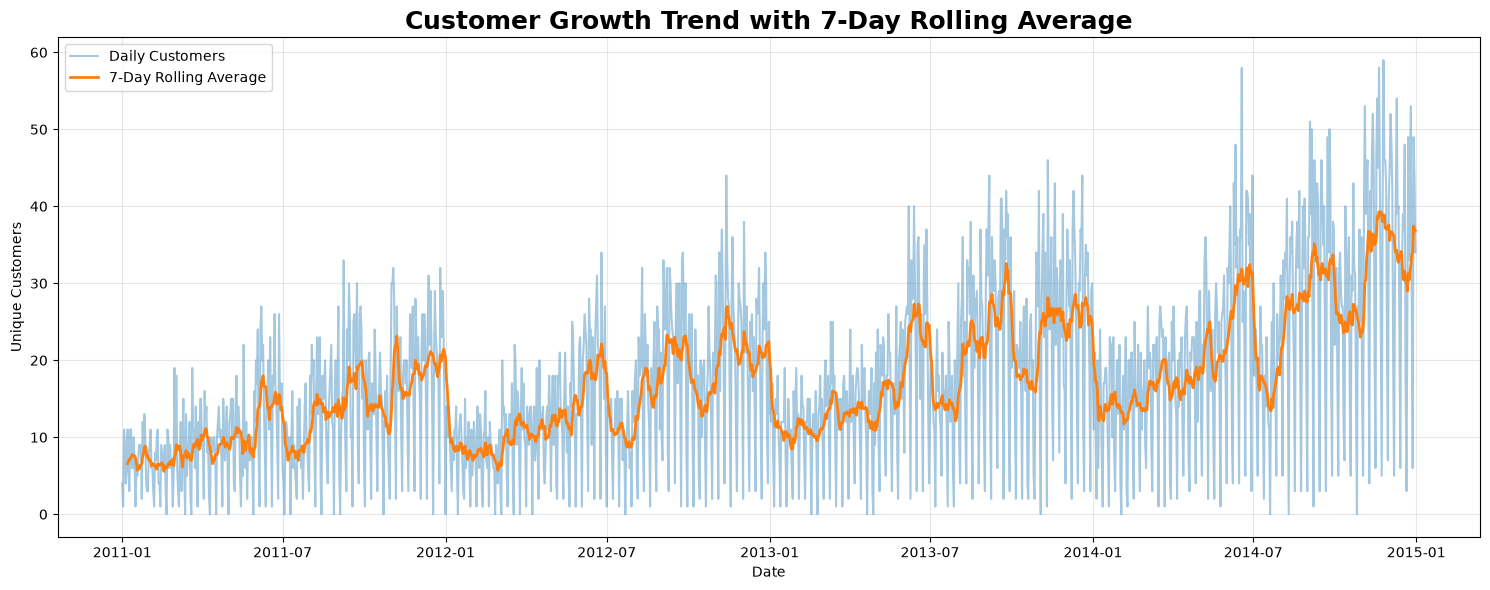

Smoothed customer growth trend created successfully!


In [7]:
# Visualize actual customers and 7-day rolling trend

plt.figure(figsize=(15, 6))

plt.plot(
    daily_customers["date"],
    daily_customers["unique_customers"],
    alpha=0.4,
    label="Daily Customers"
)

plt.plot(
    daily_customers["date"],
    daily_customers["rolling_7_day"],
    linewidth=2,
    label="7-Day Rolling Average"
)

plt.title(
    "Customer Growth Trend with 7-Day Rolling Average",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Unique Customers")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

print("Smoothed customer growth trend created successfully!")

In [8]:
# Calculate monthly unique customers

monthly_customers = (
    df.groupby(
        df["order_date"].dt.to_period("M")
    )["customer_name"]
    .nunique()
    .reset_index()
)

monthly_customers["order_date"] = (
    monthly_customers["order_date"]
    .dt.to_timestamp()
)

monthly_customers.columns = [
    "month",
    "unique_customers"
]

print("Monthly customer growth data created successfully!")

print("\nMonthly data shape:", monthly_customers.shape)

display(monthly_customers.head(10))

Monthly customer growth data created successfully!

Monthly data shape: (48, 2)


,month,unique_customers
0,2011-01-01,195
1,2011-02-01,163
2,2011-03-01,235
3,2011-04-01,228
4,2011-05-01,240
5,2011-06-01,341
6,2011-07-01,219
7,2011-08-01,325
8,2011-09-01,381
9,2011-10-01,314


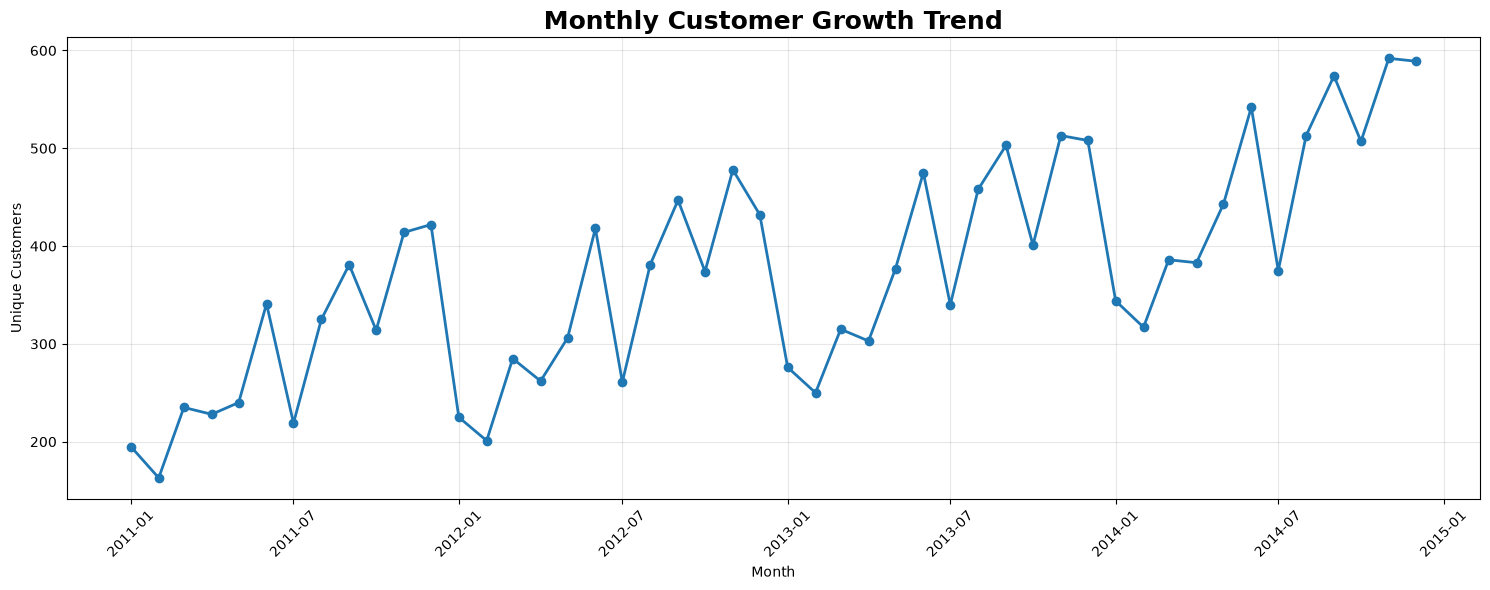

Monthly customer growth visualization created successfully!


In [9]:
# Visualize monthly customer growth

plt.figure(figsize=(15, 6))

plt.plot(
    monthly_customers["month"],
    monthly_customers["unique_customers"],
    marker="o",
    linewidth=2
)

plt.title(
    "Monthly Customer Growth Trend",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Unique Customers")

plt.grid(True, alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

print("Monthly customer growth visualization created successfully!")

In [10]:
# Analyze weekly customer patterns

daily_customers["day_of_week"] = (
    daily_customers["date"].dt.day_name()
)

weekly_pattern = (
    daily_customers
    .groupby("day_of_week")["unique_customers"]
    .mean()
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
)

print("Weekly customer pattern calculated successfully!")

display(
    weekly_pattern.reset_index(
        name="average_customers"
    )
)

Weekly customer pattern calculated successfully!


,day_of_week,average_customers
0,Monday,21.712919
1,Tuesday,21.727273
2,Wednesday,21.325359
3,Thursday,20.875000
4,Friday,21.711538
5,Saturday,11.009569
6,Sunday,2.277512


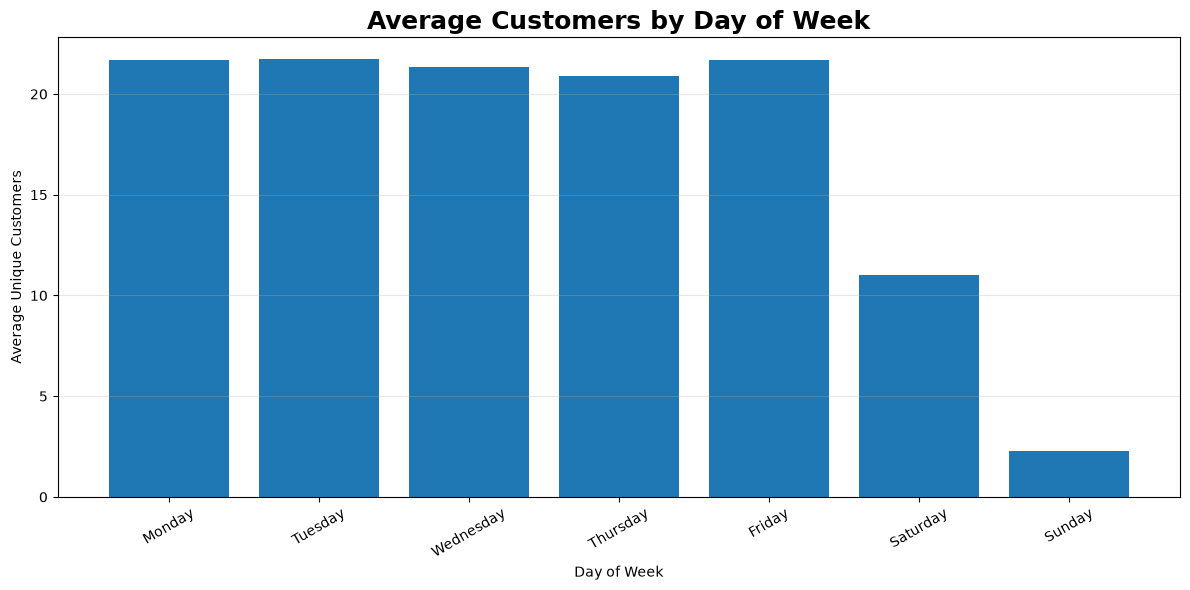

Weekly seasonality visualization created successfully!


In [11]:
# Visualize weekly customer seasonality

plt.figure(figsize=(12, 6))

plt.bar(
    weekly_pattern.index,
    weekly_pattern.values
)

plt.title(
    "Average Customers by Day of Week",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Day of Week")
plt.ylabel("Average Unique Customers")

plt.xticks(rotation=30)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

print("Weekly seasonality visualization created successfully!")

In [12]:
# Prepare forecasting dataset

forecast_data = daily_customers[
    ["date", "unique_customers"]
].copy()

forecast_data = forecast_data.sort_values("date")

forecast_data = forecast_data.set_index("date")

print("Forecasting dataset prepared successfully!")

print("\nForecasting dataset shape:")
print(forecast_data.shape)

print("\nDate range:")
print(
    forecast_data.index.min(),
    "to",
    forecast_data.index.max()
)

display(forecast_data.head(10))

Forecasting dataset prepared successfully!

Forecasting dataset shape:
(1461, 1)

Date range:
2011-01-01 00:00:00 to 2014-12-31 00:00:00


,unique_customers
date,
2011-01-01,4
2011-01-02,1
2011-01-03,11
2011-01-04,9
2011-01-05,4
2011-01-06,6
2011-01-07,11
2011-01-08,6
2011-01-09,3


In [13]:
# Create baseline forecasting model

last_7_days = forecast_data["unique_customers"].tail(7)

baseline_value = last_7_days.mean()

print("Baseline forecasting model created successfully!")

print("\nLast 7 days customer counts:")
print(last_7_days.values)

print("\nBaseline forecast value:")
print(round(baseline_value, 2))

Baseline forecasting model created successfully!

Last 7 days customer counts:
[46 53 26  6 49 44 34]

Baseline forecast value:
36.86


In [14]:
# Generate 30-day customer growth forecast

last_date = forecast_data.index.max()

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=30,
    freq="D"
)

forecast = pd.DataFrame({
    "date": future_dates,
    "predicted_customers": baseline_value
})

print("30-day customer growth forecast created successfully!")

print("\nForecast period:")
print(
    forecast["date"].min(),
    "to",
    forecast["date"].max()
)

print("\nNumber of forecast days:")
print(len(forecast))

display(forecast.head(10))

30-day customer growth forecast created successfully!

Forecast period:
2015-01-01 00:00:00 to 2015-01-30 00:00:00

Number of forecast days:
30


C:\Users\arjun\AppData\Local\Temp\ipykernel_17720\3090103147.py:6: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  start=last_date + pd.Timedelta(days=1),


,date,predicted_customers
0,2015-01-01,36.857143
1,2015-01-02,36.857143
2,2015-01-03,36.857143
3,2015-01-04,36.857143
4,2015-01-05,36.857143
5,2015-01-06,36.857143
6,2015-01-07,36.857143
7,2015-01-08,36.857143
8,2015-01-09,36.857143
9,2015-01-10,36.857143


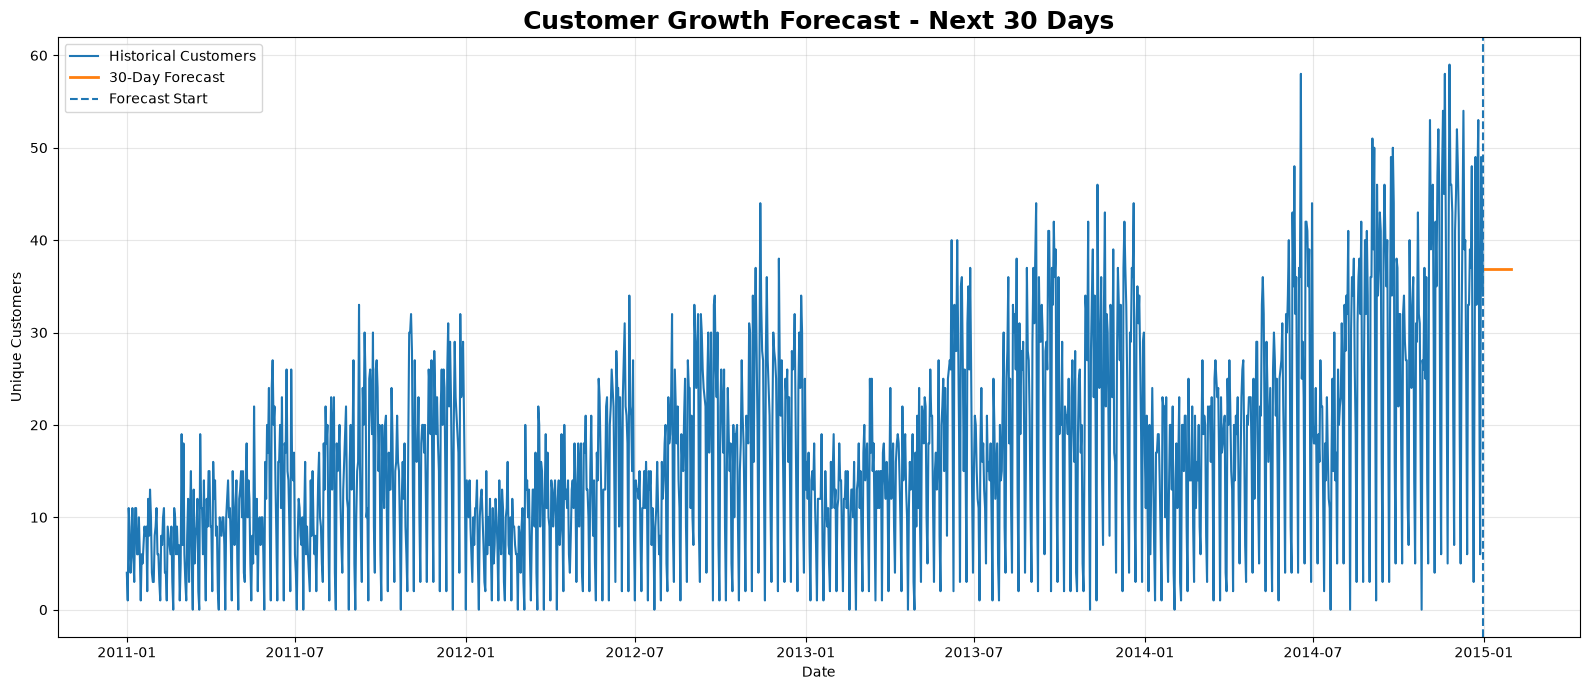

Historical and forecast trends visualized successfully!


In [15]:
# Visualize historical customer data and 30-day forecast

plt.figure(figsize=(16, 7))

# Historical data
plt.plot(
    forecast_data.index,
    forecast_data["unique_customers"],
    label="Historical Customers",
    linewidth=1.5
)

# Forecast data
plt.plot(
    forecast["date"],
    forecast["predicted_customers"],
    label="30-Day Forecast",
    linewidth=2
)

# Forecast starting point
plt.axvline(
    last_date,
    linestyle="--",
    linewidth=1.5,
    label="Forecast Start"
)

plt.title(
    "Customer Growth Forecast - Next 30 Days",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Unique Customers")

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

print("Historical and forecast trends visualized successfully!")

In [16]:
# Calculate forecast summary

forecast_average = forecast["predicted_customers"].mean()
forecast_total = forecast["predicted_customers"].sum()

historical_average = forecast_data["unique_customers"].mean()

growth_difference = (
    forecast_average - historical_average
)

growth_percentage = (
    growth_difference / historical_average
) * 100

print("FORECAST SUMMARY")
print("=" * 45)

print(
    "Historical Average Daily Customers:",
    round(historical_average, 2)
)

print(
    "Forecast Average Daily Customers:",
    round(forecast_average, 2)
)

print(
    "Expected Customers Over Next 30 Days:",
    round(forecast_total, 2)
)

print(
    "Difference from Historical Average:",
    round(growth_difference, 2)
)

print(
    "Difference Percentage:",
    round(growth_percentage, 2),
    "%"
)

print("\nForecast summary calculated successfully!")

FORECAST SUMMARY
Historical Average Daily Customers: 17.23
Forecast Average Daily Customers: 36.86
Expected Customers Over Next 30 Days: 1105.71
Difference from Historical Average: 19.63
Difference Percentage: 113.93 %

Forecast summary calculated successfully!


In [17]:
# Save 30-day forecast output

forecast_output = forecast.copy()

forecast_output["predicted_customers"] = (
    forecast_output["predicted_customers"].round(2)
)

forecast_output.to_csv(
    "customer_growth_30_day_forecast.csv",
    index=False
)

print("30-day forecast saved successfully!")
print(
    "File: customer_growth_30_day_forecast.csv"
)

print(
    "\nRows saved:",
    len(forecast_output)
)

display(forecast_output.head(10))

30-day forecast saved successfully!
File: customer_growth_30_day_forecast.csv

Rows saved: 30


,date,predicted_customers
0,2015-01-01,36.86
1,2015-01-02,36.86
2,2015-01-03,36.86
3,2015-01-04,36.86
4,2015-01-05,36.86
5,2015-01-06,36.86
6,2015-01-07,36.86
7,2015-01-08,36.86
8,2015-01-09,36.86
9,2015-01-10,36.86


# Forecasting Observations and Risks

## Observations

### 1. Historical Customer Trend

The historical customer data was converted into a daily time series to study changes in customer activity over time.

A 7-day rolling average was used to smooth daily fluctuations and make the broader trend easier to observe.

### 2. Weekly Seasonality

Average customer activity was analyzed by day of the week.

Differences between weekdays can indicate a weekly seasonal pattern in customer activity.

### 3. Baseline Forecast

A simple 7-day average baseline was used to predict customer activity for the next 30 days.

This approach provides an easy-to-understand benchmark for future forecasting models.

### 4. Forecast Interpretation

The 30-day predictions represent expected daily customer activity based on recent historical behavior.

The predictions should be treated as estimates rather than guaranteed future customer counts.

---

# Forecasting Risks

## 1. Simple Baseline Model

The model uses the recent 7-day average and does not explicitly learn long-term trends or seasonal patterns.

## 2. External Events

Marketing campaigns, holidays, promotions, economic conditions, and unexpected business events can change customer behavior.

These factors are not included in the current model.

## 3. Historical Data Limitations

The forecast depends on the quality and time range of the historical dataset.

Changes in customer behavior over time may reduce forecast accuracy.

## 4. Seasonality

The current baseline does not explicitly model weekly or monthly seasonality.

A more advanced model could incorporate these patterns.

## 5. Forecast Uncertainty

Forecast values should be treated as estimates.

Actual customer activity may be higher or lower than the predicted values.

---

# Future Improvements

Future versions could use:

- Moving-average forecasting
- Exponential smoothing
- ARIMA
- Seasonal ARIMA
- Prophet
- Additional business features
- Holiday and promotion information
- Longer historical time periods
- Forecast confidence intervals

The current baseline provides a simple starting point for understanding customer growth forecasting.

In [18]:
# Create final forecasting summary table

forecast_summary = pd.DataFrame({
    "Metric": [
        "Historical Data Start",
        "Historical Data End",
        "Historical Average Daily Customers",
        "Baseline Forecast Daily Customers",
        "Forecast Period",
        "Forecast Days",
        "Expected Customers - Next 30 Days"
    ],
    "Value": [
        forecast_data.index.min().strftime("%Y-%m-%d"),
        forecast_data.index.max().strftime("%Y-%m-%d"),
        round(historical_average, 2),
        round(baseline_value, 2),
        f"{forecast['date'].min().strftime('%Y-%m-%d')} to "
        f"{forecast['date'].max().strftime('%Y-%m-%d')}",
        len(forecast),
        round(forecast_total, 2)
    ]
})

print("Final forecasting summary created successfully!")

display(forecast_summary)

Final forecasting summary created successfully!


,Metric,Value
0,Historical Data Start,2011-01-01
1,Historical Data End,2014-12-31
2,Historical Average Daily Customers,17.23
3,Baseline Forecast Daily Customers,36.86
4,Forecast Period,2015-01-01 to 2015-01-30
5,Forecast Days,30
6,Expected Customers - Next 30 Days,1105.71


In [19]:
# Save final forecasting summary

forecast_summary.to_csv(
    "forecast_summary.csv",
    index=False
)

print("Forecast summary saved successfully!")
print("File: forecast_summary.csv")
print("Rows saved:", len(forecast_summary))

Forecast summary saved successfully!
File: forecast_summary.csv
Rows saved: 7


In [20]:
# DAY 36 - FINAL FILE CHECK

import os

required_files = [
    "day36.ipynb",
    "README.md",
    "customer_growth_30_day_forecast.csv",
    "forecast_summary.csv"
]

print("DAY 36 FILE CHECK")
print("=" * 45)

for file in required_files:
    if os.path.exists(file):
        print(f"✓ {file} - Found")
    else:
        print(f"✗ {file} - Missing")

print("\nDay 36 file check completed!")

DAY 36 FILE CHECK
✓ day36.ipynb - Found
✓ README.md - Found
✓ customer_growth_30_day_forecast.csv - Found
✓ forecast_summary.csv - Found

Day 36 file check completed!
